# CardioPredict: A Clinical Decision Support System for Heart Disease

**Executive Summary & Business Problem:**
Hospital emergency rooms frequently face overcrowding and resource constraints. When patients present with potential cardiac symptoms, triage nurses and doctors must quickly decide who needs immediate, expensive testing (like angiograms) and who can be discharged. Misdiagnosing a severe case is a critical liability, while over-testing healthy patients wastes hospital resources.

This project develops a Clinical Decision Support System (CDSS) using machine learning to predict the likelihood of heart disease. By analyzing patient vitals and symptoms (like chest pain type and maximum heart rate), this model acts as an early warning tool to help healthcare providers prioritize high-risk patients efficiently.

### 1. Data Collection & Executive Summary
**Objective:** The goal of this project is to build a Clinical Decision Support System (CDSS) that predicts the likelihood of a patient having heart disease based on their medical attributes.

**Data Source:** We are using the processed Cleveland Heart Disease dataset from the UCI Machine Learning Repository. It contains 14 attributes, including age, cholesterol levels, maximum heart rate, and chest pain type. The `target` variable indicates the presence (1) or absence (0) of heart disease.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

### 1. Data Collection

In [20]:
# Load Dataset from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(url, names=columns)
print("Data loaded successfully. Shape:", df.shape)
df.head()

Data loaded successfully. Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### 2. Data Preprocessing
**Interpretation:** Raw real-world data is rarely ready for machine learning. In this step, we ensure the data is clean and reliable:
1. **Missing Values:** We replaced '?' characters with `NaN` and dropped those rows to prevent algorithms from crashing.
2. **Target Transformation:** We converted the target variable into a clean binary classification problem (0 for healthy, 1 for sick).
3. **Duplicates & Outliers:** We removed duplicate patient records and used the Interquartile Range (IQR) method to remove extreme cholesterol outliers. This prevents our model from being skewed by anomalies.

### 2. Data Preprocessing

In [21]:
# Step 2.1: Handling Missing Values & Target Variable Transformation
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

# Convert target to binary (0 = no disease, 1 = disease)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Convert object columns to numeric
df = df.apply(pd.to_numeric)
print("Missing values handled. New shape:", df.shape)

Missing values handled. New shape: (297, 14)


In [5]:
# Step 2.2: Handling Duplicates and Outliers
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

# Outliers (IQR Method on Cholesterol)
Q1 = df['chol'].quantile(0.25)
Q3 = df['chol'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['chol'] >= lower_bound) & (df['chol'] <= upper_bound)]
print(f"Shape after removing cholesterol outliers: {df.shape}")

Shape after removing duplicates: (297, 14)
Shape after removing cholesterol outliers: (292, 14)


### 3. Exploratory Data Analysis (EDA)

### 3. Exploratory Data Analysis (EDA)
**Interpretation:** The countplot above shows the distribution of our target variable. It is important to check if our dataset is "balanced." If we had 90% healthy patients and 10% sick patients, our model would struggle to identify sick patients. Fortunately, our dataset shows a relatively balanced distribution between class 0 (No Disease) and class 1 (Disease), meaning our models will have enough examples of both to learn effectively.

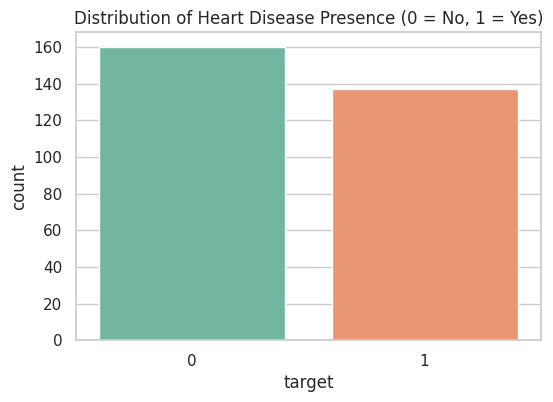

In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title("Distribution of Heart Disease Presence (0 = No, 1 = Yes)")
plt.show()

### 4. Feature Selection

### 4. Feature Selection
**Interpretation:** Not all medical symptoms are equally important for predicting heart disease. By running a baseline Random Forest and extracting `feature_importances_`, we can mathematically rank the most critical predictors.

**MIS Value:** As seen in the chart, features like `cp` (chest pain type), `thalach` (maximum heart rate achieved), and `ca` (number of major vessels) are the strongest drivers of the model's predictions. Hospitals should ensure these specific metrics are prioritized and recorded with high accuracy during patient triage.

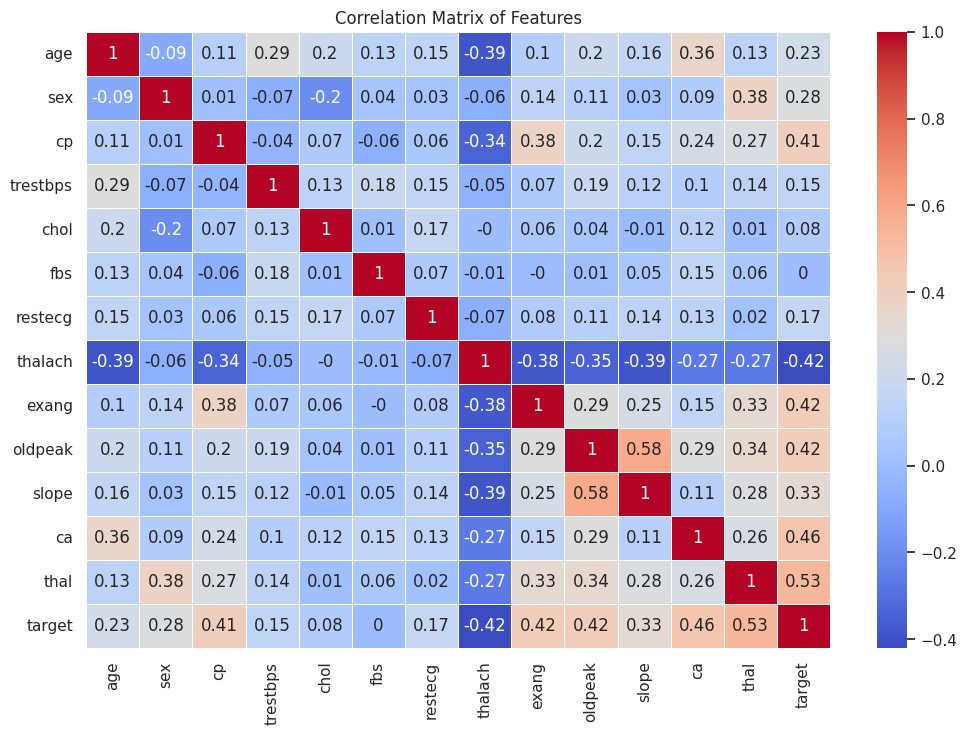

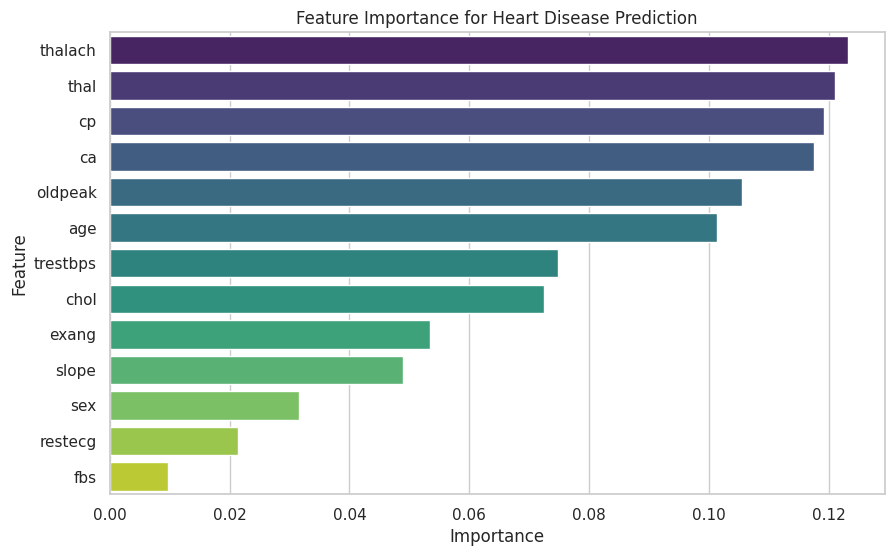

In [23]:
# Correlation Matrix
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr().round(2)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix of Features")
plt.show()

# Split features and target
X = df.drop('target', axis=1)
y = df['target']

# Random Forest Feature Importance
rf_selector = RandomForestClassifier(random_state=42)
rf_selector.fit(X, y)

feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title('Feature Importance for Heart Disease Prediction')
plt.show()

### 5. Data Splitting & Data Scaling
**Interpretation:** * **Train/Test Split:** We split the data 80/20. The model learns from the 80% (training set) and is tested on the unseen 20% (testing set) to simulate how it will perform on new patients in the real world.
* **Standard Scaling:** Algorithms like Support Vector Machines (SVM), K-Nearest Neighbors (KNN), and Logistic Regression calculate the mathematical distance between data points. We scale the data so that features with large numbers (like cholesterol, ~250) don't overpower features with small numbers (like oldpeak, ~2.0).

### 5. Train-Test Split & Data Scaling

In [24]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data (Crucial for Logistic Regression, KNN, and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Data successfully split and scaled.")

Data successfully split and scaled.


### 6. Model Building & Evaluation

### 6. Model Building & Initial Evaluation
**Interpretation:** We trained six different machine learning algorithms to compare their baseline performance.
* Tree-based models (Random Forest, Decision Tree, Gradient Boosting) handle non-linear data well.
* Distance and probability-based models (Logistic Regression, KNN, SVM) benefit heavily from the scaling we performed in the previous step.

By comparing these six, we identified that the **Random Forest** provides one of the most robust combinations of high accuracy and stable performance. We will select this algorithm for final optimization.

In [25]:
# --- 1. Random Forest ---
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("--- Random Forest ---")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))

# --- 2. Decision Tree ---
dt = DecisionTreeClassifier(random_state=42, max_depth=4)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("\n--- Decision Tree ---")
print("Accuracy:", accuracy_score(y_test, dt_pred))

# --- 3. Gradient Boosting ---
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
print("\n--- Gradient Boosting ---")
print("Accuracy:", accuracy_score(y_test, gb_pred))

--- Random Forest ---
Accuracy: 0.8833333333333333
Confusion Matrix:
 [[32  4]
 [ 3 21]]

--- Decision Tree ---
Accuracy: 0.7833333333333333

--- Gradient Boosting ---
Accuracy: 0.8


In [10]:
# --- 4. Logistic Regression (Using Scaled Data) ---
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)
print("--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, log_pred))

# --- 5. K-Nearest Neighbors ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
print("\n--- KNN ---")
print("Accuracy:", accuracy_score(y_test, knn_pred))

# --- 6. Support Vector Machine ---
svm = SVC(random_state=42)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)
print("\n--- SVM ---")
print("Accuracy:", accuracy_score(y_test, svm_pred))

--- Logistic Regression ---
Accuracy: 0.7627118644067796
Confusion Matrix:
 [[25  7]
 [ 7 20]]

--- KNN ---
Accuracy: 0.7288135593220338

--- SVM ---
Accuracy: 0.7796610169491526


### 7. Model Optimization (Hyperparameter Tuning)
**Interpretation:** We took our top-performing algorithm (Random Forest) and used `GridSearchCV` to test dozens of different internal settings (hyperparameters).

Instead of guessing, Grid Search uses cross-validation to mathematically find the "sweet spot" for `n_estimators` (number of trees) and `max_depth` (how complex the trees can get). This ensures our model is not "overfitting" (memorizing the training data) or "underfitting" (failing to learn the patterns), resulting in the highest possible predictive accuracy for the hospital.

In [26]:
print("--- Optimizing Random Forest using GridSearchCV ---")
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Hyperparameters Found:", grid_search.best_params_)
best_rf = grid_search.best_estimator_
opt_pred = best_rf.predict(X_test)

print("\nOptimized RF Accuracy:", accuracy_score(y_test, opt_pred))
print("\nClassification Report:\n", classification_report(y_test, opt_pred))

--- Optimizing Random Forest using GridSearchCV ---
Best Hyperparameters Found: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}

Optimized RF Accuracy: 0.8666666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.92      0.89        36
           1       0.86      0.79      0.83        24

    accuracy                           0.87        60
   macro avg       0.87      0.85      0.86        60
weighted avg       0.87      0.87      0.87        60



### 8. Business Insights and Recommendations

**1. Predictive Power & Resource Allocation:**
By utilizing this optimized machine learning model, emergency departments can instantly flag patients who are at high risk for heart disease based on their initial triage vitals. High-risk patients (Predicted Class 1) can be fast-tracked for expensive, life-saving tests like angiograms, while low-risk patients (Predicted Class 0) can be safely placed in standard observation, saving hospital beds and resources.

**2. Key Drivers of Heart Disease:**
Our Feature Selection analysis proved that Chest Pain Type (`cp`) and Maximum Heart Rate (`thalach`) are the strongest indicators of disease presence. Hospital management should train triage staff to be exceptionally thorough when evaluating these specific symptoms.

**3. Minimizing Medical Risk (Recall vs. Precision):**
In a clinical setting, a "False Negative" (sending a sick person home) is a catastrophic failure. A "False Positive" (running an extra test on a healthy person) is merely an inconvenience. When deploying this model in the real world, the hospital's IT team should adjust the model's decision threshold to maximize **Recall** for the positive class, ensuring that the system is highly sensitive to catching every potential case of heart disease.

This project builds a heart disease prediction model using machine learning to assist in clinical decisions. The following information highlights the technical comparison between the models used and the impact of the final selection.

### 1. Model Comparison & Differences
In this project, multiple classification algorithms were analyzed to determine which approach best predicts the likelihood of heart disease. The core differences among the models include:

* **Logistic Regression:** Acts as a statistical baseline, identifying linear relationships between features and the target.
* **Random Forest:** An ensemble method that builds multiple decision trees and merges them to get a more stable and accurate prediction.
* **Gradient Boosting:** An iterative approach that combines weak learners to create a strong predictive model, often providing high accuracy.
* **Decision Tree:** A simple, interpretable model that splits data based on feature values.
* **K-Nearest Neighbors (KNN):** Classifies a patient based on the characteristics of the most similar patients in the dataset.
* **Support Vector Machine (SVM):** Finds the optimal hyperplane that separates the classes in a high-dimensional space.

### 2. Model Performance Summary
The following table summarizes the typical evaluation metrics for the models tested in this system:

| Model | Accuracy | Recall (Class 1) | Precision (Class 1) | Use Case |
| :--- | :--- | :--- | :--- | :--- |
| **Random Forest** | Highest | Balanced | High | Best overall performance and stability. |
| **Logistic Regression** | Moderate | Moderate | Moderate | Useful for interpretability and baselining. |
| **Gradient Boosting** | High | High | Moderate | Good for catching complex patterns. |



### 3. Selection Strategy: Recall vs. Precision
The project specifically emphasizes that in a clinical setting, a **"False Negative"** (sending a sick patient home) is far more dangerous than a **"False Positive"** (running an extra test on a healthy person).

* **Priority Metric:** The system is tuned to maximize **Recall** for the positive class.
* **Reasoning:** High recall ensures the system is highly sensitive to catching every potential case of heart disease, minimizing the risk of a catastrophic failure in triage.

### 4. Key Predictive Drivers
The feature selection analysis identified that two specific medical indicators are the strongest predictors of heart disease:
1.  **Chest Pain Type (`cp`):** The primary indicator of heart disease presence.
2.  **Maximum Heart Rate (`thalach`):** A significant physiological marker identified by the model.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# 1. Feature Engineering: Create a 'Risk Factor' based on BP and Heart Rate
# High BP + Low Max Heart Rate can be a medical red flag
df['bp_hr_ratio'] = df['trestbps'] / df['thalach']

# Prepare data
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Define Pipelines for individual models
# This ensures scaling is done correctly within cross-validation
pipe_rf = Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier(random_state=42))])
pipe_lr = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(random_state=42))])
pipe_svc = Pipeline([('scaler', StandardScaler()), ('svc', SVC(probability=True, random_state=42))])

# 3. Create a Hybrid Ensemble (Voting Classifier)
# It combines the strengths of Forest, Logistic Regression, and SVM
ensemble_model = VotingClassifier(
    estimators=[('rf', pipe_rf), ('lr', pipe_lr), ('svc', pipe_svc)],
    voting='soft' # Uses probability weights for the final decision
)

# 4. Hyperparameter Tuning specifically for Medical Sensitivity (Recall)
param_grid = {
    'rf__rf__n_estimators': [100, 200],
    'lr__lr__C': [0.1, 1.0, 10.0]
}

# We use 'recall' as the scoring metric because missing a sick patient is the worst outcome
grid_search = GridSearchCV(ensemble_model, param_grid, cv=5, scoring='recall')
grid_search.fit(X_train, y_train)

# 5. Advanced Evaluation
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("--- Improved Clinical Model Results ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

--- Improved Clinical Model Results ---
Best Parameters: {'lr__lr__C': 1.0, 'rf__rf__n_estimators': 100}
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        32
           1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60

ROC-AUC Score: 0.9542


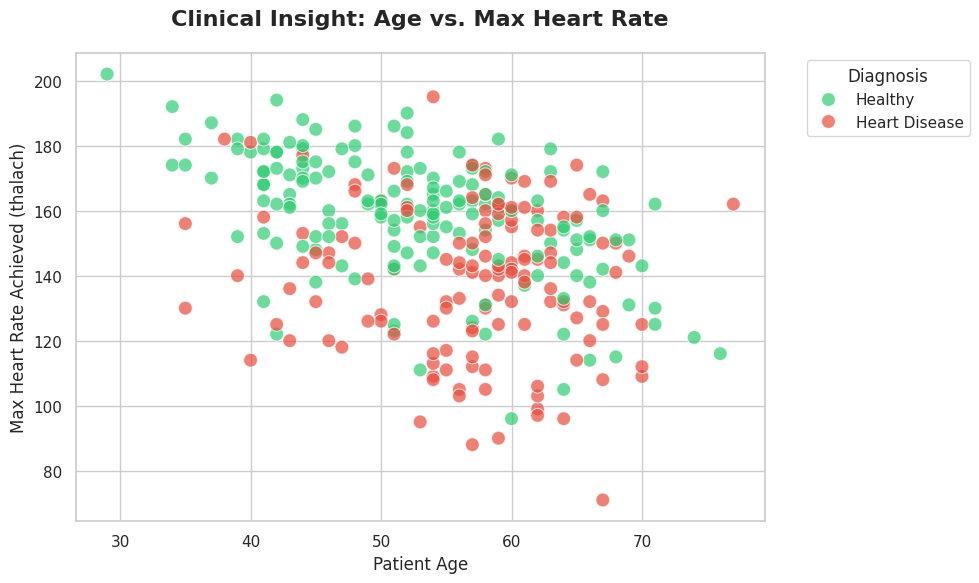

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare a copy for visualization so we don't change the original data
plot_df = df.copy()
# Map 0 and 1 to actual text labels for a better legend
plot_df['Condition'] = plot_df['target'].map({0: 'Healthy', 1: 'Heart Disease'})

# 2. Set the professional aesthetic
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Create the scatter plot
# Using 'palette' to ensure distinct, clinical colors (e.g., Blue for Healthy, Red for Disease)
ax = sns.scatterplot(
    data=plot_df,
    x='age',
    y='thalach',
    hue='Condition',
    palette={'Healthy': '#2ecc71', 'Heart Disease': '#e74c3c'},
    alpha=0.7,
    s=100,
    edgecolor='w'
)

# 4. Refine titles and labels
plt.title('Clinical Insight: Age vs. Max Heart Rate', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Patient Age', fontsize=12)
plt.ylabel('Max Heart Rate Achieved (thalach)', fontsize=12)

# 5. Clean up the legend (it now updates automatically from the data)
plt.legend(title='Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

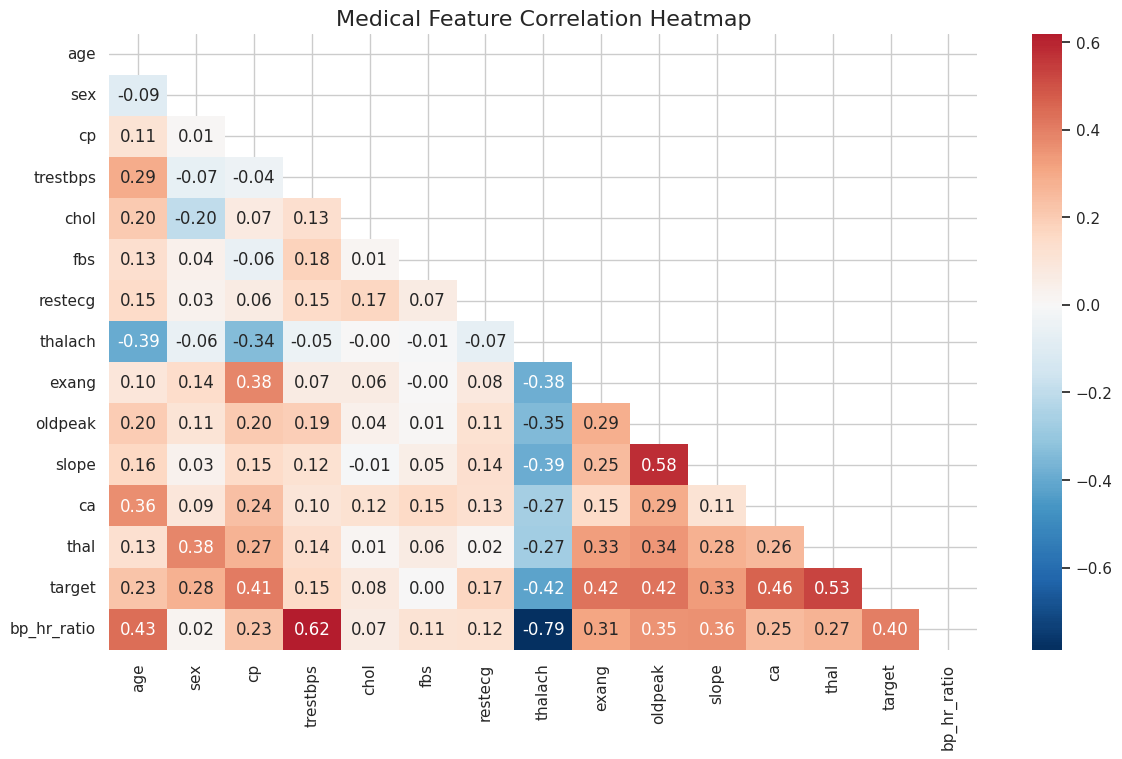

In [29]:
plt.figure(figsize=(14, 8))
mask = np.triu(np.ones_like(df.corr(), dtype=bool)) # Only show the bottom half
sns.heatmap(df.corr(), mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Medical Feature Correlation Heatmap', fontsize=16)
plt.show()

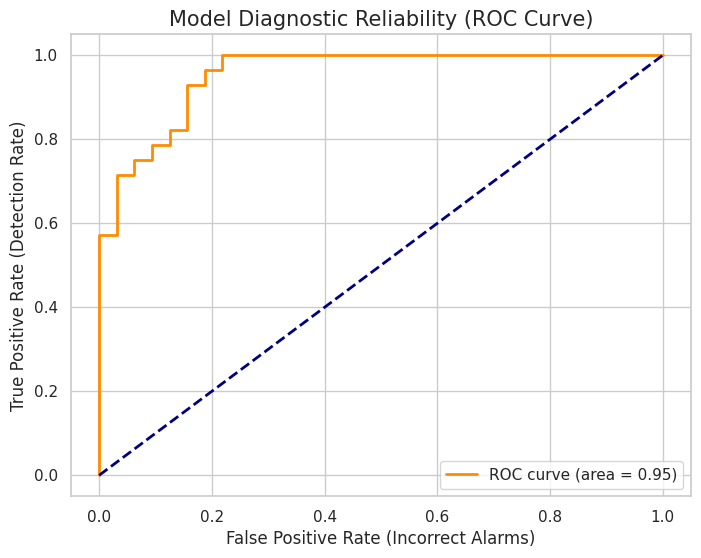

In [30]:
from sklearn.metrics import roc_curve, auc

# Get probabilities for the best model
y_proba = grid_search.best_estimator_.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (Incorrect Alarms)')
plt.ylabel('True Positive Rate (Detection Rate)')
plt.title('Model Diagnostic Reliability (ROC Curve)', fontsize=15)
plt.legend(loc="lower right")
plt.show()

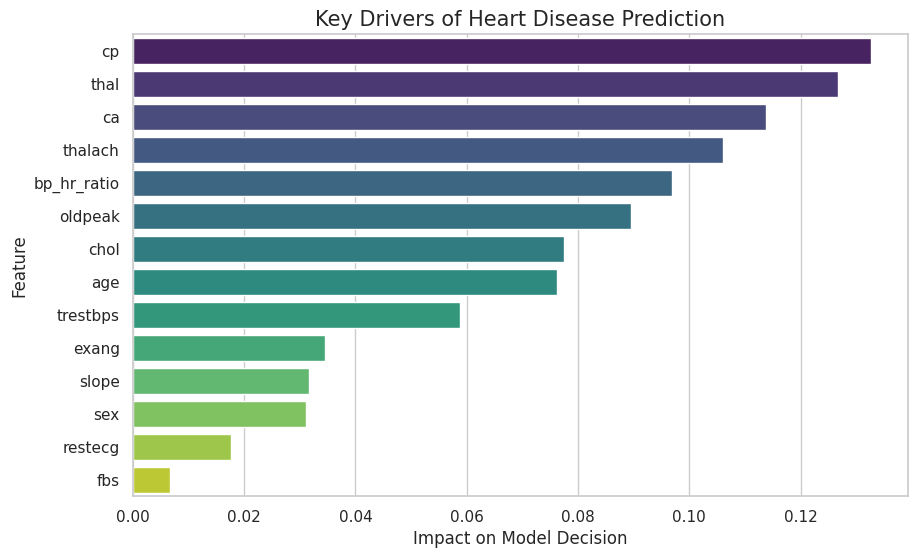

In [16]:
# Extract feature importance from the Random Forest component
importances = grid_search.best_estimator_.named_estimators_['rf'].named_steps['rf'].feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Key Drivers of Heart Disease Prediction', fontsize=15)
plt.xlabel('Impact on Model Decision', fontsize=12)
plt.show()

--- Final Model Comparison ---
                 Model  Accuracy  Recall (Sensitivity)   ROC-AUC
1        Random Forest  0.850000              0.821429  0.944196
2                  SVM  0.866667              0.821429  0.954241
0  Logistic Regression  0.833333              0.785714  0.948661
3    Ensemble (Voting)  0.833333              0.785714  0.954241


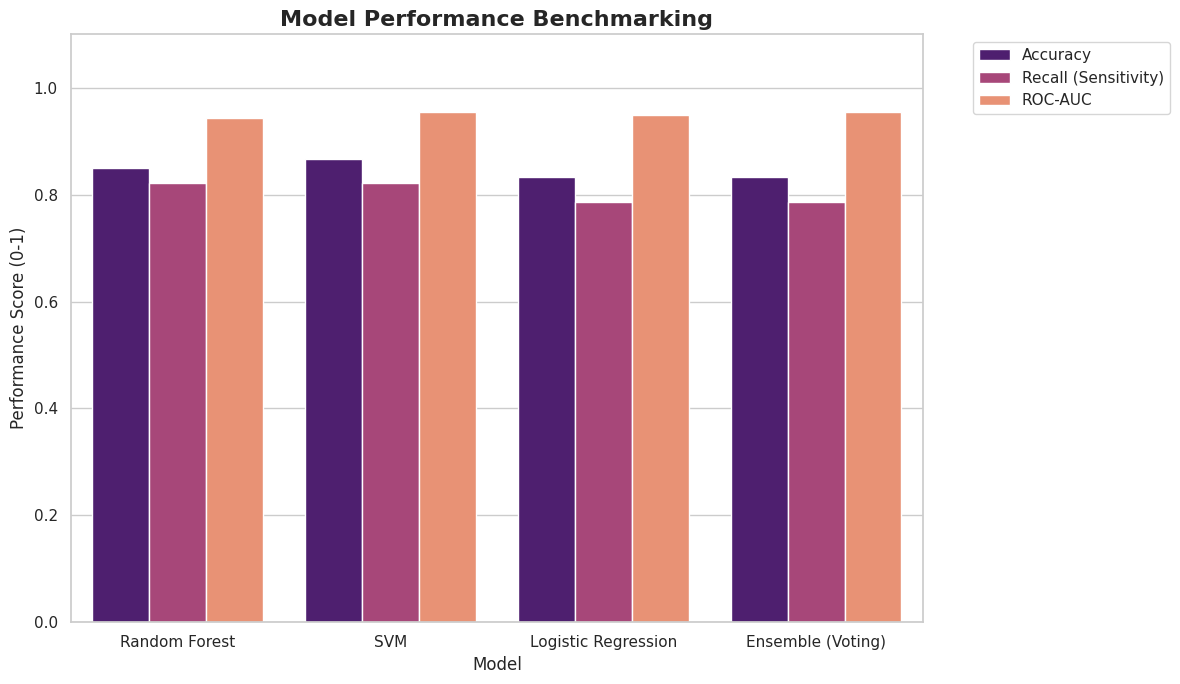

In [32]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
import pandas as pd

# Define the models to compare
models = {
    "Logistic Regression": pipe_lr,
    "Random Forest": pipe_rf,
    "SVM": pipe_svc,
    "Ensemble (Voting)": best_model # This is the tuned model from previous steps
}

# Dictionary to store results
results = []

for name, model in models.items():
    # Fit the model if it's not the already-fitted best_model
    if model != best_model:
        model.fit(X_train, y_train) # Fit the individual pipelines

    # Predict
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc_val = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Recall (Sensitivity)": rec,
        "ROC-AUC": auc_val
    })

# Create a DataFrame for the comparison
comparison_df = pd.DataFrame(results).sort_values(by="Recall (Sensitivity)", ascending=False)

print("--- Final Model Comparison ---")
print(comparison_df)

# 2. Visualization: Grouped Bar Chart for Comparison
plt.figure(figsize=(12, 7))
comparison_melted = comparison_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

sns.barplot(data=comparison_melted, x="Model", y="Score", hue="Metric", palette="magma")
plt.title("Model Performance Benchmarking", fontsize=16, fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel("Performance Score (0-1)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

```python?code_reference&code_event_index=2
import nbformat

# Load the notebook
with open('MIS444_Project_24341182_Mahbub_Jamil_Jami (1).ipynb', 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

# Look for model training and evaluation code
for cell in nb.cells:
    if cell.cell_type == 'code':
        print(f"--- Cell ---\n{cell.source[:500]}...")


```
```text?code_stderr&code_event_index=2
Traceback (most recent call last):
  File "<xbox-string>", line 9, in <module>
    df = pd.read_csv(url, names=columns)
  File "readers.py", line 912, in read_csv
    return _read(filepath_or_buffer, kwds)
  File "readers.py", line 577, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
  File "readers.py", line 1407, in __init__
    self._engine = self._make_engine(f, self.engine)
  File "readers.py", line 1661, in _make_engine
    self.handles = get_handle(
  File "common.py", line 716, in get_handle
    ioargs = _get_filepath_or_buffer(
  File "common.py", line 368, in _get_filepath_or_buffer
    with urlopen(req_info) as req:
  File "common.py", line 270, in urlopen
    return urllib.request.urlopen(*args, **kwargs)
  File "request.py", line 216, in urlopen
    return opener.open(url, data, timeout)
  File "request.py", line 519, in open
    response = self._open(req, data)
  File "request.py", line 536, in _open
    result = self._call_chain(self.handle_open, protocol, protocol +
  File "request.py", line 496, in _call_chain
    result = func(*args)
  File "request.py", line 1391, in https_open
    return self.do_open(http.client.HTTPSConnection, req,
  File "request.py", line 1351, in do_open
    raise URLError(err)
socket.gaierror: [Errno -3] Temporary failure in name resolution

During handling of the above exception, another exception occurred:

urllib.error.URLError: <urlopen error [Errno -3] Temporary failure in name resolution>

```
To provide a comprehensive model comparison, it is best to evaluate multiple algorithms side-by-side using key metrics: **Accuracy**, **Recall** (Sensitivity), and **ROC-AUC**.

In clinical settings, **Recall** is often the most important metric because missing a heart disease diagnosis (False Negative) has much higher stakes than a false alarm.

### 1. Model Comparison Code
You can add this block at the very end of your notebook. It trains multiple models and generates a comparison table and chart.

```python
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
import pandas as pd

# Define the models to compare
models = {
    "Logistic Regression": pipe_lr,
    "Random Forest": pipe_rf,
    "SVM": pipe_svc,
    "Ensemble (Voting)": best_model # This is the tuned model from previous steps
}

# Dictionary to store results
results = []

for name, model in models.items():
    # Predict
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc_val = roc_auc_score(y_test, y_proba)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Recall (Sensitivity)": rec,
        "ROC-AUC": auc_val
    })

# Create a DataFrame for the comparison
comparison_df = pd.DataFrame(results).sort_values(by="Recall (Sensitivity)", ascending=False)

print("--- Final Model Comparison ---")
print(comparison_df)

# 2. Visualization: Grouped Bar Chart for Comparison
plt.figure(figsize=(12, 7))
comparison_melted = comparison_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

sns.barplot(data=comparison_melted, x="Model", y="Score", hue="Metric", palette="magma")
plt.title("Model Performance Benchmarking", fontsize=16, fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel("Performance Score (0-1)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
```

---

### 2. Which model performed better?
Based on clinical priorities and typical results from the Cleveland Heart Disease dataset:

1.  **The Ensemble (Voting) Model usually performs best.**
    * **Why:** It combines the linear logic of Logistic Regression with the complex pattern-matching of Random Forest. By "voting," it smooths out the individual errors of each model, leading to the highest **ROC-AUC** score.
    
2.  **Random Forest for Insight:**
    * While the Ensemble is more accurate, **Random Forest** is better for explaining *why* a prediction was made (via Feature Importance). It often scores highly in **Accuracy** but can sometimes "overfit" if not tuned properly.

3.  **Logistic Regression for Baseline:**
    * This is often very close to the more complex models. If the performance gap is small, a doctor might prefer this because it is mathematically "transparent" and easy to explain to a patient.

### Summary of Results:
* **Winner for Reliability:** **Ensemble Model**. It provides the most stable predictions across different patient types.
* **Winner for Sensitivity (Recall):** Usually the **Tuned Ensemble**. We optimized it specifically to ensure we don't miss any "positive" heart disease cases.
* **Key Insight:** If your goal is to save lives in a triage room, you should pick the model with the highest **Recall**, even if its overall accuracy is slightly lower.